# Angle, length, and assignment scores (all optimizers)

For every `(experiment_id, optimizer_id)` in [`scan_results()`](../app.py), compute **`angles_scores`**, **`length_scores`**, and **`assignment_scores`** only — the same definitions as in [`compare_all_optimizers.ipynb`](compare_all_optimizers.ipynb) (`score_run` before expert saliency / MSSIM / representation similarity).

No GPU work and no expert checkpoints. Checkpoints are written under `SAVE_DIR` (default `local/save/OTHER/`).


In [46]:
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [47]:
import gzip
import hashlib
import pickle
import sys
from pathlib import Path
from typing import Any, cast

import numpy as np
import pandas as pd
from tqdm.auto import tqdm


def _find_project_root(start: Path | None = None) -> Path:
	p = (start or Path.cwd()).resolve()
	for cand in [p, *p.parents]:
		if (cand / "pyproject.toml").is_file():
			return cand
	return p


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
	sys.path.insert(0, str(PROJECT_ROOT))

from visualize_webapp.app import (
	_NETWORK_SAMPLES_PER_DIGIT,
	_metrics,
	_nts,
	_sort_optimizer_ids,
	scan_results,
)
from visualize_webapp.notebook.scoring_helpers import (
	angle_score_function,
	filter_periods,
	find_impacted_periods,
	get_assignments,
	get_iteration,
	get_n_assigned_digits,
	get_period_angles,
	get_recovery_periods,
	length_score_function,
	n_active_decay,
	n_partial_decay,
	remove_inelligible_periods,
	index_grp,
)
from visualize_webapp.post_processing import _pp_dead, _pp_neuron_digit

STRICT = False
BTSP_START_STRATEGY = "acceleration"
USE_REAL_PROGRESSION = True
SAVE_DIR = "local/save/OTHER/"


def _run_checkpoint_dir(save_dir: str, eid: str, oid: str) -> Path:
	sha = hashlib.sha256(f"{eid}-{oid}".encode("utf-8")).hexdigest()[:7]
	return Path(save_dir) / sha


def _save_run_checkpoint(save_dir: str, eid: str, oid: str, out: dict[str, Any]) -> None:
	d = _run_checkpoint_dir(save_dir, eid, oid)
	d.mkdir(parents=True, exist_ok=True)
	pd.DataFrame([{"eid": eid, "oid": oid}]).to_csv(d / "key.csv", index=False)
	with gzip.open(d / "results.pkl.gz", "wb", compresslevel=9) as f:
		pickle.dump(out, f, protocol=pickle.HIGHEST_PROTOCOL)


def _load_run_checkpoint(save_dir: str, eid: str, oid: str) -> dict[str, Any] | None:
	d = _run_checkpoint_dir(save_dir, eid, oid)
	key_csv = d / "key.csv"
	res_gz = d / "results.pkl.gz"
	res_pkl = d / "results.pkl"
	if not key_csv.is_file() or (not res_gz.is_file() and not res_pkl.is_file()):
		return None
	key_df = pd.read_csv(key_csv)
	if len(key_df) != 1 or str(key_df["eid"].iloc[0]) != str(eid) or str(key_df["oid"].iloc[0]) != str(oid):
		return None
	if res_gz.is_file():
		with gzip.open(res_gz, "rb") as f:
			return pickle.load(f)
	with open(res_pkl, "rb") as f:
		return pickle.load(f)


def _empty_period_score_frames() -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
	midx = pd.MultiIndex.from_arrays([[], []], names=index_grp)
	angles_scores = pd.DataFrame(index=midx, columns=["angle_score", "activation_angle"])
	length_scores = pd.DataFrame(index=midx, columns=["length_score"])
	assignment_scores = pd.DataFrame(
		index=midx, columns=["n_partial_decay_score", "n_active_decay_score"]
	)
	return angles_scores, length_scores, assignment_scores


def other_scores_run(
	eid: str,
	mid: str,
	oid: str,
	rid: str,
	project_root: Path | None = None,
) -> dict[str, Any]:
	# Angle / length / assignment score tables per period (same as score_run early stage).
	_ = project_root or PROJECT_ROOT
	metrics = _metrics(eid, mid, oid, rid=rid, w_cache=False)
	df_nd = cast(pd.DataFrame, _pp_neuron_digit(eid, mid, oid, rid=rid, w_cache=False))
	if df_nd is None or df_nd.empty:
		return {"error": "empty neuron_digit", "eid": eid, "mid": mid, "oid": oid, "rid": rid}

	df_nd = df_nd.copy()
	df_nd["n_active"] = df_nd["status"].apply(
		lambda s: 0
		if s == "inactive"
		else (_NETWORK_SAMPLES_PER_DIGIT if s == "assigned" else int(s.split("_")[-1]))
	)
	df_nd["iteration"] = df_nd["checkpoint_idx"].map(lambda c: get_iteration(metrics, c))

	df_dead = cast(pd.DataFrame, _pp_dead(eid, mid, oid, rid=rid, w_cache=False))
	if df_dead is not None and not df_dead.empty:
		df_dead = df_dead.copy()
		df_dead["iteration"] = df_dead["checkpoint_idx"].map(lambda c: get_iteration(metrics, c))

	nts = _nts(eid, mid, oid, rid=rid, w_cache=False)

	n_assigned_digits = get_n_assigned_digits(df_nd)
	recovery_periods_any = get_recovery_periods(
		metrics, df_nd, n_assigned_digits, df_dead, mode="assigned_any"
	)
	recovery_periods_same = get_recovery_periods(
		metrics, df_nd, n_assigned_digits, df_dead, mode="assigned_same"
	)
	impacted = find_impacted_periods(recovery_periods_any, recovery_periods_same)
	n_any = len(recovery_periods_any)
	impacted_pct = float(len(impacted) / n_any) if n_any else 0.0

	recovery_periods = recovery_periods_same
	recovery_periods = remove_inelligible_periods(recovery_periods)
	if df_dead is not None and not df_dead.empty:
		recovery_periods = filter_periods(recovery_periods, df_dead, strict=STRICT)

	if recovery_periods.empty:
		ang, leng, asn = _empty_period_score_frames()
		return {
			"eid": eid,
			"mid": mid,
			"oid": oid,
			"rid": rid,
			"impacted_pct": impacted_pct,
			"angles_scores": ang,
			"length_scores": leng,
			"assignment_scores": asn,
		}

	period_angles = get_period_angles(
		nts,
		recovery_periods,
		from_point=BTSP_START_STRATEGY,
		use_real_progression=USE_REAL_PROGRESSION,
	)
	angles_scores = period_angles.assign(
		angle_score=lambda df: df["activation_angle"].map(angle_score_function)
	)

	length_scores = (
		recovery_periods[index_grp + ["total_length_iter"]]
		.assign(length_score=lambda df: df["total_length_iter"].map(length_score_function))
		.drop(columns=["total_length_iter"])
		.set_index(index_grp)
	)

	assignments = get_assignments(df_nd, recovery_periods)
	assignment_scores = assignments.groupby(index_grp, sort=False).apply(
		lambda df: pd.Series(
			{
				"n_partial_decay_score": n_partial_decay(int(df["n_partial_at_start"].iloc[0])),
				"n_active_decay_score": n_active_decay(int(df["n_assigned_at_start"].iloc[0])),
			}
		)
	)

	return {
		"eid": eid,
		"mid": mid,
		"oid": oid,
		"rid": rid,
		"impacted_pct": impacted_pct,
		"angles_scores": angles_scores,
		"length_scores": length_scores,
		"assignment_scores": assignment_scores,
	}


In [48]:
tree = scan_results()
all_results: dict[tuple[str, str], dict] = {}
errors: list[dict] = []


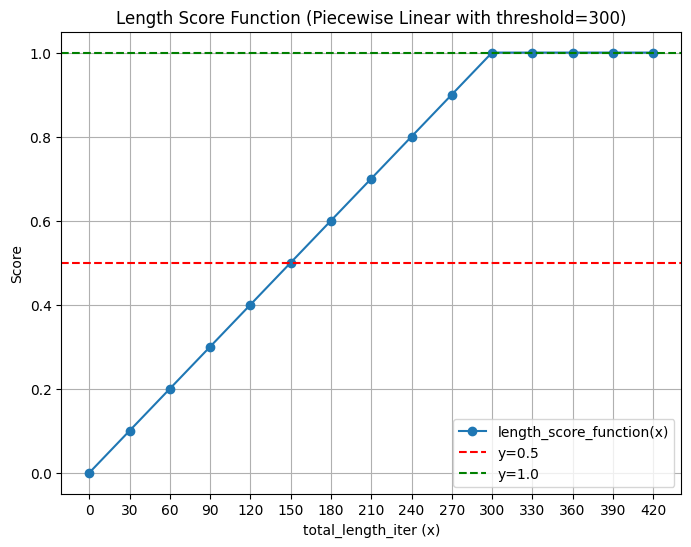

In [55]:
import matplotlib.pyplot as plt
def plot_length_function():
	threshold = 3 * 100
	x_int = np.arange(0, threshold + 5 * (threshold // 10), step=threshold // 10)
	y_length = np.array([length_score_function(xi) for xi in x_int])

	plt.figure(figsize=(8, 6))
	plt.plot(x_int, y_length, marker="o", label="length_score_function(x)")
	plt.axhline(0.5, color="red", linestyle="--", label="y=0.5")
	plt.axhline(1.0, color="green", linestyle="--", label="y=1.0")
	plt.xlabel("total_length_iter (x)")
	plt.ylabel("Score")
	plt.title(f"Length Score Function (Piecewise Linear with threshold={threshold})")
	plt.legend()
	plt.grid(True)
	plt.xticks(x_int)
	plt.show()


plot_length_function()

In [49]:
for eid, models in tqdm(sorted(tree.items()), desc="Experiments"):
	for mid, runs in sorted(models.items()):
		for rid, oids in sorted(runs.items()):
			for oid in _sort_optimizer_ids(list(oids)):
				key = (eid, oid)
				if key in all_results:
					print(f"Skipping {key} because it already exists in memory")
					continue
				loaded = _load_run_checkpoint(SAVE_DIR, eid, oid)
				if loaded is not None:
					all_results[key] = loaded
					print(f"Loaded {key} from checkpoint")
					continue
				out = other_scores_run(eid, mid, oid, rid, PROJECT_ROOT)
				_save_run_checkpoint(SAVE_DIR, eid, oid, out)
				all_results[key] = out
				if "error" in out:
					errors.append(out)

print(f"Computed other scores for {len(all_results)} (eid, oid) pairs; {len(errors)} errors")


Experiments:   0%|          | 0/4 [00:00<?, ?it/s]

Removing 5 period(s) that do not last until the end of their trial.
Removing: neuron_id            dnn|hidden.6|neuron|1
layer_name                        hidden.6
period_id                                0
start                                  305
end                                  306.0
start_iter                             301
end_iter                               302
total_length_iter                        1
Name: 0, dtype: object

Removing: neuron_id            dnn|hidden.6|neuron|13
layer_name                         hidden.6
period_id                                 0
start                                   305
end                                   306.0
start_iter                              301
end_iter                                302
total_length_iter                         1
Name: 2, dtype: object

Removing: neuron_id            dnn|hidden.8|neuron|2
layer_name                        hidden.8
period_id                                0
start                        

/tmp/ipykernel_936509/1287255405.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_936509/1287255405.py:87: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([_opt_display(o) for o in opt_order], rotation=25, ha="right")
/tmp/ipykernel_936509/1287255405.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_936509/1287255405.py:87: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([_opt_display(o) for o in opt_order], rotation=25, ha="right")
/tmp/ipykernel

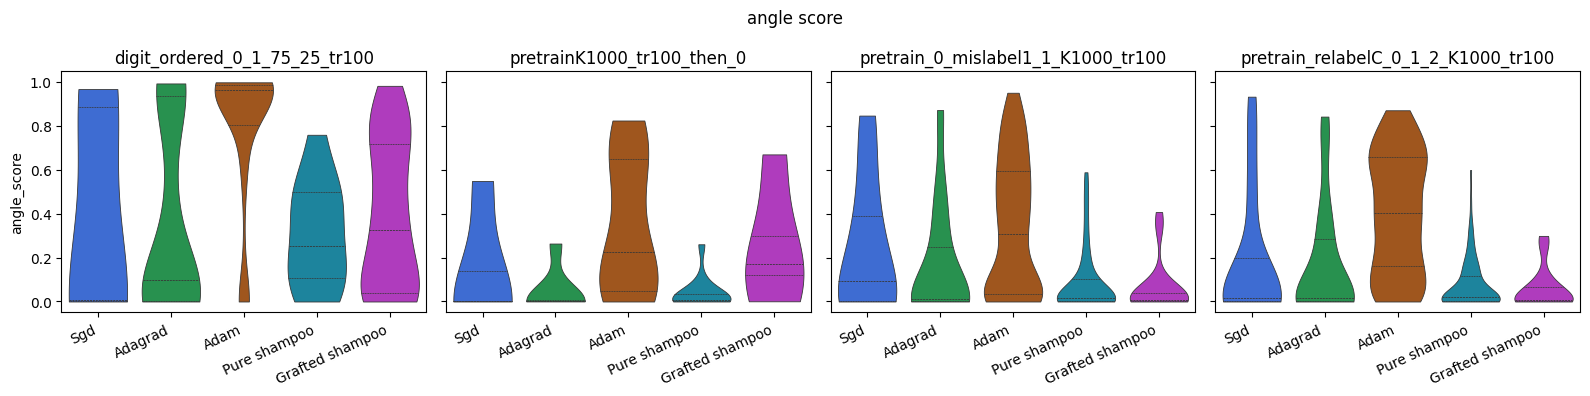

/tmp/ipykernel_936509/1287255405.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_936509/1287255405.py:87: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([_opt_display(o) for o in opt_order], rotation=25, ha="right")
/tmp/ipykernel_936509/1287255405.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_936509/1287255405.py:87: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([_opt_display(o) for o in opt_order], rotation=25, ha="right")
/tmp/ipykernel

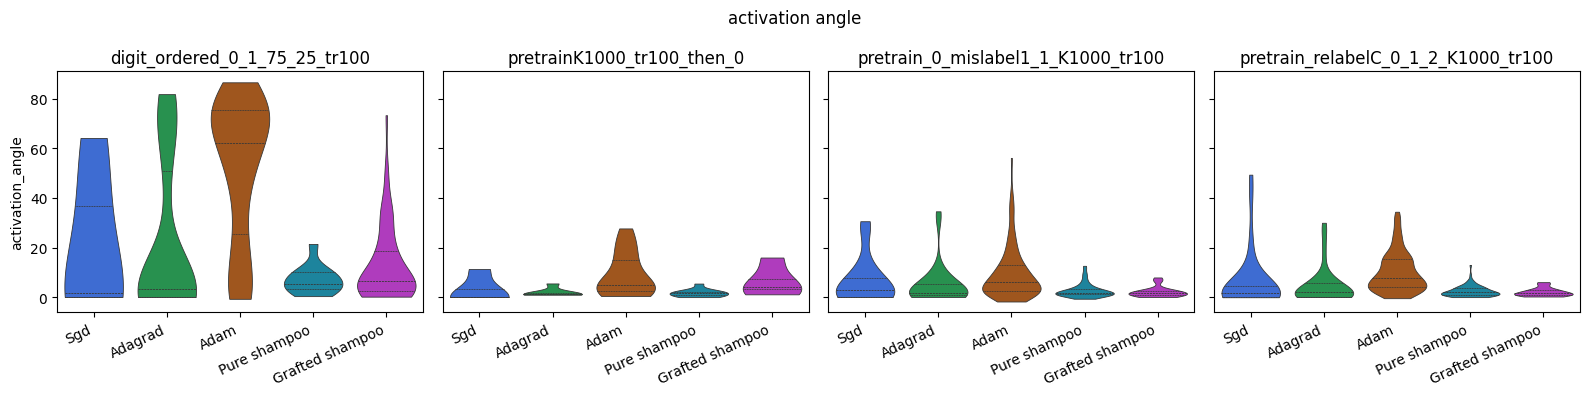

/tmp/ipykernel_936509/1287255405.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_936509/1287255405.py:87: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([_opt_display(o) for o in opt_order], rotation=25, ha="right")
/tmp/ipykernel_936509/1287255405.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_936509/1287255405.py:87: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([_opt_display(o) for o in opt_order], rotation=25, ha="right")
/tmp/ipykernel

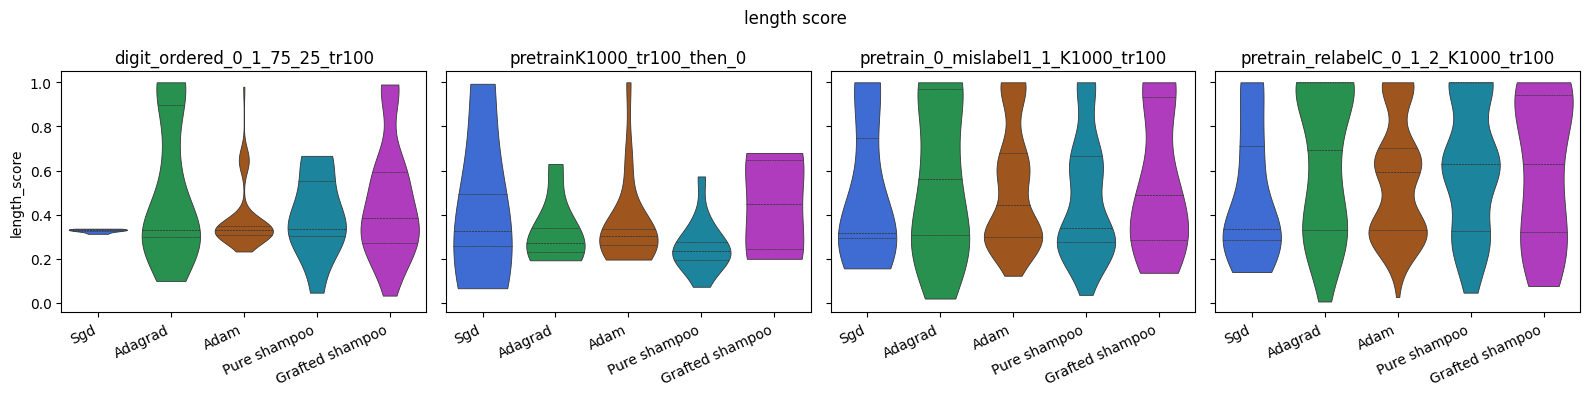

/tmp/ipykernel_936509/1287255405.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_936509/1287255405.py:87: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([_opt_display(o) for o in opt_order], rotation=25, ha="right")
/tmp/ipykernel_936509/1287255405.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_936509/1287255405.py:87: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([_opt_display(o) for o in opt_order], rotation=25, ha="right")
/tmp/ipykernel

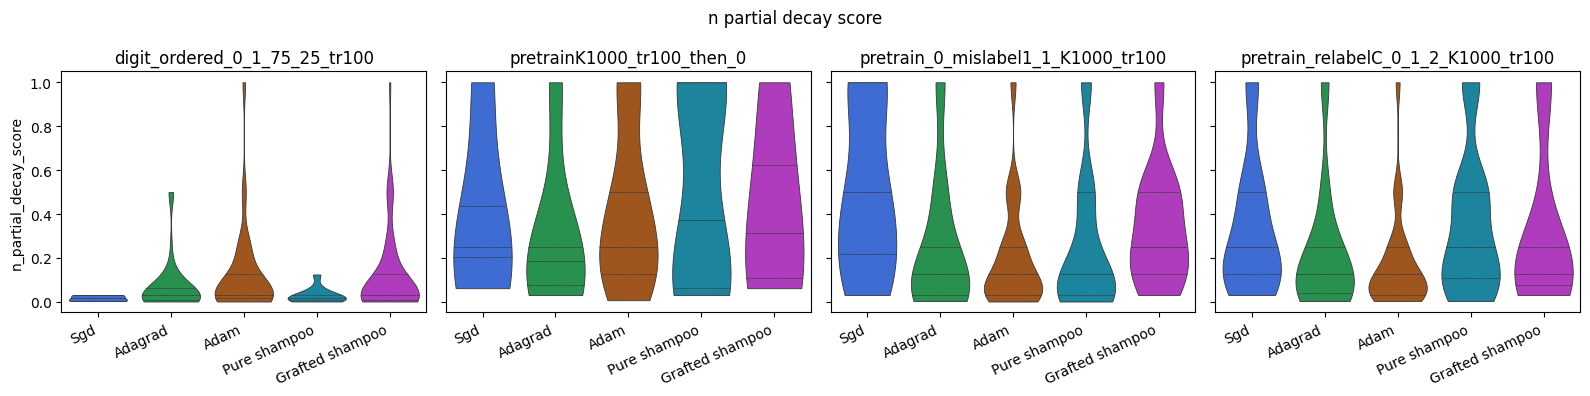

/tmp/ipykernel_936509/1287255405.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_936509/1287255405.py:87: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([_opt_display(o) for o in opt_order], rotation=25, ha="right")
/tmp/ipykernel_936509/1287255405.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_936509/1287255405.py:87: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([_opt_display(o) for o in opt_order], rotation=25, ha="right")
/tmp/ipykernel

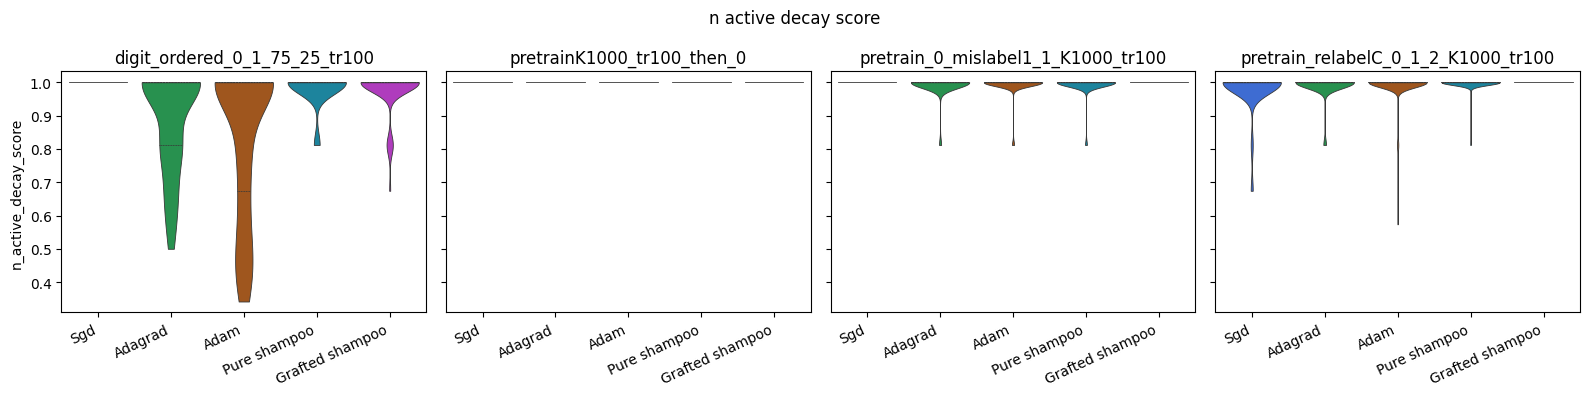

In [50]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from visualize_webapp.app import _opt_color, _sort_optimizer_ids


def _opt_display(oid: str) -> str:
	no_lr = oid.rsplit("_lr", 1)[0] if "_lr" in oid else oid
	return no_lr.replace("_", " ").capitalize()


def _build_other_scores_long(all_results: dict) -> pd.DataFrame:
	specs = [
		("angles_scores", ["angle_score", "activation_angle"]),
		("length_scores", ["length_score"]),
		("assignment_scores", ["n_partial_decay_score", "n_active_decay_score"]),
	]
	rows: list[dict] = []
	for (eid, oid), out in all_results.items():
		if out.get("error"):
			continue
		for table, cols in specs:
			df = out.get(table)
			if df is None or df.empty:
				continue
			for col in cols:
				if col not in df.columns:
					continue
				for v in df[col].dropna().to_numpy():
					rows.append(
						{
							"experiment_id": eid,
							"optimizer_id": oid,
							"score": col,
							"value": float(v),
						}
					)
	return pd.DataFrame(rows)


df_scores = _build_other_scores_long(all_results)
if df_scores.empty:
	print("No score rows to plot (run the main loop first or check errors).")
else:
	experiments = sorted(df_scores["experiment_id"].unique())
	opt_order = _sort_optimizer_ids(df_scores["optimizer_id"].unique().tolist())
	colors = [_opt_color(o) for o in opt_order]
	score_order = [
		c
		for c in [
			"angle_score",
			"activation_angle",
			"length_score",
			"n_partial_decay_score",
			"n_active_decay_score",
		]
		if c in df_scores["score"].unique()
	]

	for score_name in score_order:
		fig, axes = plt.subplots(
			1,
			len(experiments),
			figsize=(max(4 * len(experiments), 6), 4),
			sharey=True,
			squeeze=False,
		)
		for ax, eid in zip(axes[0], experiments):
			sub = df_scores[
				(df_scores["experiment_id"] == eid) & (df_scores["score"] == score_name)
			]
			if sub.empty:
				ax.text(0.5, 0.5, "no data", ha="center", va="center", transform=ax.transAxes)
				ax.set_xticks([])
			else:
				sns.violinplot(
					data=sub,
					x="optimizer_id",
					y="value",
					hue="optimizer_id",
					order=opt_order,
					hue_order=opt_order,
					palette=colors,
					legend=False,
					dodge=False,
					cut=0,
					inner="quartile",
					linewidth=0.6,
					ax=ax,
				)
				ax.set_xticks(range(len(opt_order)))
				ax.set_xticklabels(
					[_opt_display(o) for o in opt_order], rotation=25, ha="right"
				)
			ax.set_title(eid)
			ax.set_xlabel("")
		axes[0][0].set_ylabel(score_name)
		fig.suptitle(score_name.replace("_", " "))
		plt.tight_layout()
		plt.show()


In [51]:
# Print all keys in all_results
print(all_results.keys())

# Print the keys for an example entry
print(all_results[('digit_ordered_0_1_75_25_tr100', 'sgd_lr0.01')].keys())

# Print keys and all (neuron_id, period_id) pairs with angle_score > 10
for result_key, result_val in all_results.items():
	angle_scores = result_val.get('angles_scores')
	if angle_scores is not None:
		# Find where angle_score > 10
		mask = angle_scores['angle_score'] > 10
		if mask.any():
			print(f"\nKey: {result_key}")
			# angles_scores should be a DataFrame indexed by (neuron_id, period_id)
			idxs = angle_scores[mask].index
			for neuron_id, period_id in idxs:
				row = angle_scores.loc[(neuron_id, period_id)]
				score = row["angle_score"]
				aa = row["activation_angle"] if "activation_angle" in angle_scores.columns else float("nan")
				print(
					f"  neuron_id: {neuron_id}, period_id: {period_id}, "
					f"angle_score: {score}, activation_angle (deg): {aa}"
				)

dict_keys([('digit_ordered_0_1_75_25_tr100', 'sgd_lr0.01'), ('digit_ordered_0_1_75_25_tr100', 'adagrad_lr0.01'), ('digit_ordered_0_1_75_25_tr100', 'adam_lr0.01'), ('digit_ordered_0_1_75_25_tr100', 'pure_shampoo_lr0.01'), ('digit_ordered_0_1_75_25_tr100', 'grafted_shampoo_lr0.01'), ('pretrainK1000_tr100_then_0', 'sgd_lr0.01'), ('pretrainK1000_tr100_then_0', 'adagrad_lr0.01'), ('pretrainK1000_tr100_then_0', 'adam_lr0.01'), ('pretrainK1000_tr100_then_0', 'pure_shampoo_lr0.01'), ('pretrainK1000_tr100_then_0', 'grafted_shampoo_lr0.01'), ('pretrain_0_mislabel1_1_K1000_tr100', 'sgd_lr0.01'), ('pretrain_0_mislabel1_1_K1000_tr100', 'adagrad_lr0.01'), ('pretrain_0_mislabel1_1_K1000_tr100', 'adam_lr0.01'), ('pretrain_0_mislabel1_1_K1000_tr100', 'pure_shampoo_lr0.01'), ('pretrain_0_mislabel1_1_K1000_tr100', 'grafted_shampoo_lr0.01'), ('pretrain_relabelC_0_1_2_K1000_tr100', 'sgd_lr0.01'), ('pretrain_relabelC_0_1_2_K1000_tr100', 'adagrad_lr0.01'), ('pretrain_relabelC_0_1_2_K1000_tr100', 'adam_lr0.01

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from typing import cast

import pandas as pd
from visualize_webapp.app import _metrics, _nts
from visualize_webapp.notebook.network_analysis_mpl import (
	mpl_neuron_eval_activation_angle_over_time,
	mpl_neuron_eval_activation_per_sample_over_time,
	_eval_act_x_aligned,
	_x_values_for_checkpoints,
)
from visualize_webapp.notebook.scoring_helpers import (
	get_iteration,
	get_n_assigned_digits,
	get_recovery_periods,
	get_trial_start_end_iter,
	remove_inelligible_periods,
	filter_periods,
)
from visualize_webapp.post_processing import _pp_dead, _pp_neuron_digit

STRICT = False  # keep in sync with `other_scores_run`


def _segment_window_for_iter_span(
	metrics: dict,
	nts: dict,
	neuron_id: str,
	iter_lo: float,
	iter_hi: float,
) -> tuple[int, int] | tuple[None, None]:
	aligned = _eval_act_x_aligned(neuron_id, nts, metrics)
	if aligned is None:
		return None, None
	_, xs, _ = aligned
	xs_arr = np.asarray(xs, dtype=np.float64)
	xs_seg = xs_arr[1:]
	if xs_seg.size == 0:
		return None, None
	lo = float(iter_lo)
	hi = float(iter_hi)
	min_idx = int(np.searchsorted(xs_seg, lo, side="left"))
	max_idx = int(np.searchsorted(xs_seg, hi, side="right"))
	min_idx = max(0, min(min_idx, xs_seg.size))
	max_idx = max(min_idx, min(max_idx, xs_seg.size))
	return min_idx, max_idx


def _period_start_checkpoint_and_start_iter(
	eid: str,
	mid: str,
	oid: str,
	rid: str,
	neuron_id: str,
	period_id,
) -> tuple[int, int] | None:
	metrics = _metrics(eid, mid, oid, rid=rid, w_cache=False)
	df_nd = cast(pd.DataFrame, _pp_neuron_digit(eid, mid, oid, rid=rid, w_cache=False))
	if df_nd is None or df_nd.empty:
		return None
	df_dead = cast(pd.DataFrame, _pp_dead(eid, mid, oid, rid=rid, w_cache=False))
	if df_dead is not None and not df_dead.empty:
		df_dead = df_dead.copy()
		df_dead["iteration"] = df_dead["checkpoint_idx"].map(lambda c: get_iteration(metrics, c))
	n_assigned_digits = get_n_assigned_digits(df_nd)
	recovery_periods = get_recovery_periods(
		metrics, df_nd, n_assigned_digits, df_dead, mode="assigned_same"
	)
	recovery_periods = remove_inelligible_periods(recovery_periods)
	if df_dead is not None and not df_dead.empty:
		recovery_periods = filter_periods(recovery_periods, df_dead, strict=STRICT)
	m = (recovery_periods["neuron_id"] == neuron_id) & (
		recovery_periods["period_id"] == period_id
	)
	row = recovery_periods.loc[m]
	if row.empty:
		return None
	return int(row["start"].iloc[0]), int(row["start_iter"].iloc[0])


for result_key, result_val in all_results.items():
	if result_val.get("error"):
		continue
	angle_scores = result_val.get("angles_scores")
	if angle_scores is None or angle_scores.empty:
		continue
	mask = angle_scores["angle_score"] > 10
	if not mask.any():
		continue
	eid, oid = result_key
	mid = result_val.get("mid")
	rid = result_val.get("rid")
	if mid is None or rid is None:
		print(f"Skip {result_key}: missing mid/rid (re-run other_scores_run to refresh cache).")
		continue
	metrics = _metrics(eid, mid, oid, rid=rid, w_cache=False)
	nts = _nts(eid, mid, oid, rid=rid, w_cache=False)
	for neuron_id, period_id in angle_scores[mask].index:
		row = angle_scores.loc[(neuron_id, period_id)]
		start_cp_start_iter = _period_start_checkpoint_and_start_iter(
			eid, mid, oid, rid, neuron_id, period_id
		)
		if start_cp_start_iter is None:
			print(f"No recovery row for {eid} {oid} {neuron_id} p{period_id}")
			continue
		start_cp, start_iter = start_cp_start_iter
		trial_start = get_trial_start_end_iter(start_iter, start=True)
		min_idx, max_idx = _segment_window_for_iter_span(
			metrics, nts, str(neuron_id), trial_start, trial_start + 200
		)
		if min_idx is None:
			print(f"No aligned timeseries for {neuron_id}")
			continue
		cp_x, _, _ = _x_values_for_checkpoints([int(start_cp)], metrics)
		cp_line = float(cp_x[0])
		print(
			f"Plot {eid} {oid} {neuron_id} period={period_id} start_cp={start_cp} "
			f"start_iter={start_iter} trial_start_iter={trial_start} cp_x={cp_line} "
			f"seg_window=[{min_idx},{max_idx}) angle_score={row['angle_score']} "
			f"activation_angle={row.get('activation_angle', float('nan'))}"
		)
		# Angle plot: min_idx/max_idx index segments (len xs - 1); raw activations index checkpoints.
		fig_a = mpl_neuron_eval_activation_angle_over_time(
			str(neuron_id),
			nts,
			metrics,
			signed_angle_y_deg_limit=90.0,
			min_idx=min_idx,
			max_idx=max_idx,
			cp=cp_line,
		)
		plt.show()
		cp_min = min_idx
		cp_max = max_idx + 1
		fig_r = mpl_neuron_eval_activation_per_sample_over_time(
			str(neuron_id),
			nts,
			metrics,
			min_idx=cp_min,
			max_idx=cp_max,
			cp=cp_line,
		)
		plt.show()


In [53]:
# All recovery periods (assigned_same, same filters as `other_scores_run`) for one neuron
NEURON_ID = "dnn|hidden.2|neuron|59"

from typing import cast

import pandas as pd
from visualize_webapp.app import _metrics
from visualize_webapp.notebook.scoring_helpers import (
	get_iteration,
	get_n_assigned_digits,
	get_recovery_periods,
	remove_inelligible_periods,
	filter_periods,
)
from visualize_webapp.post_processing import _pp_dead, _pp_neuron_digit

STRICT = False  # keep in sync with `other_scores_run`


def _recovery_periods_for_run(
	eid: str, mid: str, oid: str, rid: str
) -> pd.DataFrame | None:
	metrics = _metrics(eid, mid, oid, rid=rid, w_cache=False)
	df_nd = cast(pd.DataFrame, _pp_neuron_digit(eid, mid, oid, rid=rid, w_cache=False))
	if df_nd is None or df_nd.empty:
		return None
	df_dead = cast(pd.DataFrame, _pp_dead(eid, mid, oid, rid=rid, w_cache=False))
	if df_dead is not None and not df_dead.empty:
		df_dead = df_dead.copy()
		df_dead["iteration"] = df_dead["checkpoint_idx"].map(
			lambda c: get_iteration(metrics, c)
		)
	n_assigned_digits = get_n_assigned_digits(df_nd)
	rp = get_recovery_periods(
		metrics, df_nd, n_assigned_digits, df_dead, mode="assigned_same"
	)
	rp = remove_inelligible_periods(rp)
	if df_dead is not None and not df_dead.empty:
		rp = filter_periods(rp, df_dead, strict=STRICT)
	return rp


parts: list[pd.DataFrame] = []
for (eid, oid) in sorted(all_results.keys()):
	out = all_results[(eid, oid)]
	if out.get("error"):
		continue
	mid, rid = out.get("mid"), out.get("rid")
	if mid is None or rid is None:
		continue
	rp = _recovery_periods_for_run(eid, mid, oid, rid)
	if rp is None or rp.empty:
		continue
	sub = rp.loc[rp["neuron_id"] == NEURON_ID].copy()
	if sub.empty:
		continue
	sub.insert(0, "experiment_id", eid)
	sub.insert(1, "optimizer_id", oid)
	parts.append(sub)

if not parts:
	print(f"No periods for {NEURON_ID}.")
else:
	all_periods = pd.concat(parts, axis=0, ignore_index=True)
	with pd.option_context("display.max_rows", None, "display.width", 220, "display.max_columns", None):
		print(all_periods.to_string(index=False))


Removing 28 period(s) that do not last until the end of their trial.
Removing: neuron_id            dnn|hidden.2|neuron|46
layer_name                         hidden.2
period_id                                 0
start                                   321
end                                   326.0
start_iter                              317
end_iter                                322
total_length_iter                         5
Name: 9, dtype: object

Removing: neuron_id            dnn|hidden.4|neuron|1
layer_name                        hidden.4
period_id                                0
start                                  207
end                                  245.0
start_iter                             204
end_iter                               242
total_length_iter                       38
Name: 15, dtype: object

Removing: neuron_id            dnn|hidden.4|neuron|17
layer_name                         hidden.4
period_id                                 0
start                   

In [54]:
# is_dead for one neuron in an iteration window (uses `get_iteration` / checkpoint_iterations)
EID = "digit_ordered_0_1_75_25_tr100"
OID = "adam_lr0.01"
NEURON_ID = "dnn|hidden.2|neuron|59"
# optional context (recovery period 0 in hidden.2) — not used to filter, only printed
LAYER_NAME = "hidden.2"
PERIOD_ID = 0
ITER_LO, ITER_HI = 180,220

from typing import cast

import pandas as pd
from visualize_webapp.app import _metrics
from visualize_webapp.notebook.scoring_helpers import get_iteration
from visualize_webapp.post_processing import _pp_dead

key = (EID, OID)
if key not in all_results or all_results[key].get("error"):
	raise KeyError(f"Run {key} not in all_results or has error; load the main loop first.")
mid = all_results[key]["mid"]
rid = all_results[key]["rid"]
metrics = _metrics(EID, mid, OID, rid=rid, w_cache=False)
df_dead = cast(pd.DataFrame, _pp_dead(EID, mid, OID, rid=rid, w_cache=False))
if df_dead is None or df_dead.empty:
	raise RuntimeError("No post_processing_dead.csv for this run.")
sub = df_dead.loc[df_dead["neuron_id"] == NEURON_ID].copy()
if sub.empty:
	raise RuntimeError(f"No dead rows for {NEURON_ID}.")
sub["iteration"] = sub["checkpoint_idx"].map(lambda c: get_iteration(metrics, c))
win = sub[(sub["iteration"] >= ITER_LO) & (sub["iteration"] <= ITER_HI)].sort_values(
	"iteration"
)
cols = [c for c in ("neuron_id", "layer_name", "checkpoint_idx", "iteration", "is_dead", "is_ppd") if c in win.columns]
print(
	f"{EID} / {OID}  {NEURON_ID}  (layer {LAYER_NAME} period {PERIOD_ID} — context only)\n"
	f"iterations {ITER_LO}:{ITER_HI}  ({len(win)} row(s))\n"
)
if win.empty:
	print("No checkpoint rows in this iteration window (iterations can be sparse).")
else:
	with pd.option_context("display.max_rows", None, "display.width", 200):
		print(win[cols].to_string(index=False))


digit_ordered_0_1_75_25_tr100 / adam_lr0.01  dnn|hidden.2|neuron|59  (layer hidden.2 period 0 — context only)
iterations 180:220  (42 row(s))

             neuron_id layer_name  checkpoint_idx  iteration  is_dead  is_ppd
dnn|hidden.2|neuron|59   hidden.2             182        180    False   False
dnn|hidden.2|neuron|59   hidden.2             183        181    False   False
dnn|hidden.2|neuron|59   hidden.2             184        182    False   False
dnn|hidden.2|neuron|59   hidden.2             185        183    False   False
dnn|hidden.2|neuron|59   hidden.2             186        184    False   False
dnn|hidden.2|neuron|59   hidden.2             187        185    False   False
dnn|hidden.2|neuron|59   hidden.2             188        186    False   False
dnn|hidden.2|neuron|59   hidden.2             189        187    False   False
dnn|hidden.2|neuron|59   hidden.2             190        188    False   False
dnn|hidden.2|neuron|59   hidden.2             191        189    False   False